# ArrayGlyph

- This script demonstrates the usage of the ArrayGlyph class from the Cleopatra package.
The ArrayGlyph class provides functionality for visualizing arrays and creating animations.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np

from cleopatra.config import Config

Config.set_matplotlib_backend()
from cleopatra.animation import embed_gif
from cleopatra.array_glyph import ArrayGlyph, ColorBar, PointOverlay

# Set the random seed for reproducibility
np.random.seed(42)

## 1. Creating and Visualizing a Simple Array
Let's start by creating a simple 2D array and visualizing it with ArrayGlyph.

In [2]:
# Create a simple 2D array
simple_array = np.zeros((10, 10))
for i in range(10):
    for j in range(10):
        simple_array[i, j] = i * j  # Create a multiplication table pattern

In [3]:
# Initialize the ArrayGlyph with the array
array_glyph = ArrayGlyph(simple_array)

Array shape: (10, 10)
Min value: 0.0
Max value: 81.0


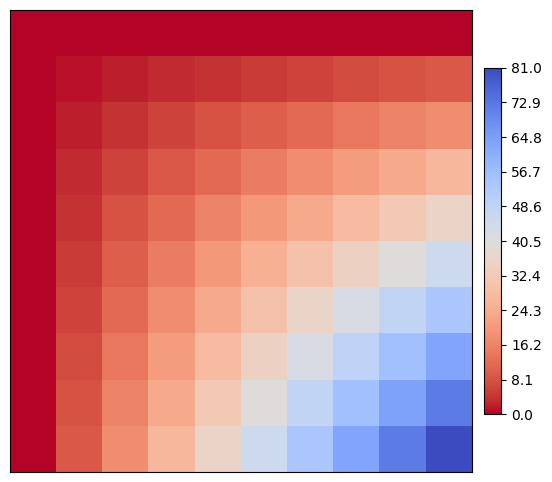

In [4]:
# Plot the array with default settings
fig, ax = array_glyph.plot()

# Display information about the array
print(f"Array shape: {simple_array.shape}")
print(f"Min value: {simple_array.min()}")
print(f"Max value: {simple_array.max()}")

## 2. Customizing the Array Visualization
The ArrayGlyph class provides many options for customizing the visualization.

Create a more complex array

In [5]:
complex_array = np.random.rand(20, 20)  # Random values between 0 and 1
complex_array[5:15, 5:15] = (
    complex_array[5:15, 5:15] * 2
)  # Increase values in the center

- Initialize the ArrayGlyph with the array

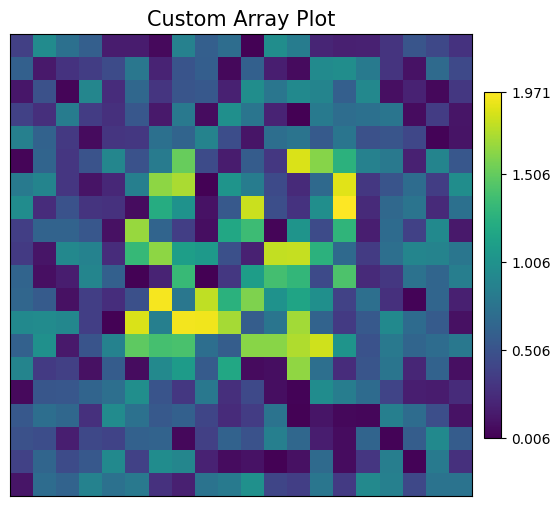

In [6]:
array_glyph_custom = ArrayGlyph(complex_array)

# Plot with custom settings
fig, ax = array_glyph_custom.plot(
    cmap="viridis",  # Use the viridis colormap
    title="Custom Array Plot",  # Add a title
    colorbar=ColorBar(ticks_spacing=0.5),  # Set tick spacing
    figsize=(10, 8),  # Set figure size
)

## 3. Using Different Color Scales
- The ArrayGlyph class supports different color scales for visualizing arrays.

- Create an array with positive and negative values

In [7]:
mixed_array = np.random.randn(15, 15)  # Random values from a normal distribution

- Initialize the ArrayGlyph with the array

In [8]:
array_glyph_scales = ArrayGlyph(mixed_array)

### 3.1 Linear Scale (default)

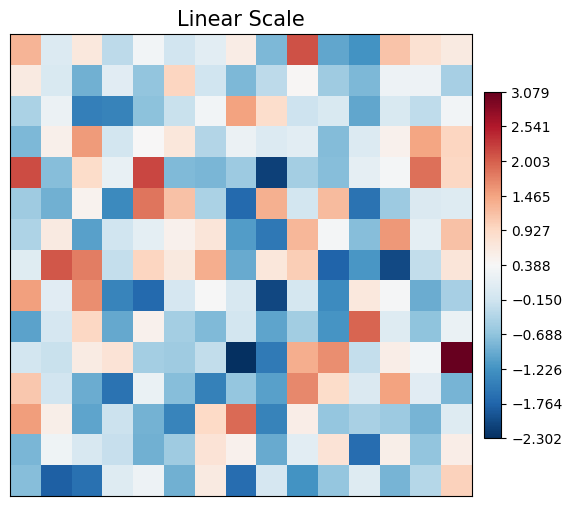

In [9]:
fig1, ax1 = array_glyph_scales.plot(
    color_scale="linear", cmap="RdBu_r", title="Linear Scale"
)

### 3.2 Power Scale

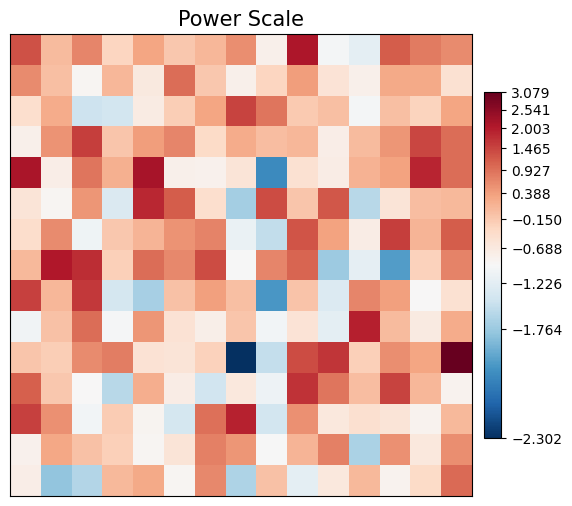

In [10]:
array_glyph_scales = ArrayGlyph(mixed_array)
fig2, ax2 = array_glyph_scales.plot(
    color_scale="power", cmap="RdBu_r", title="Power Scale"
)

### 3.3 Log Scale

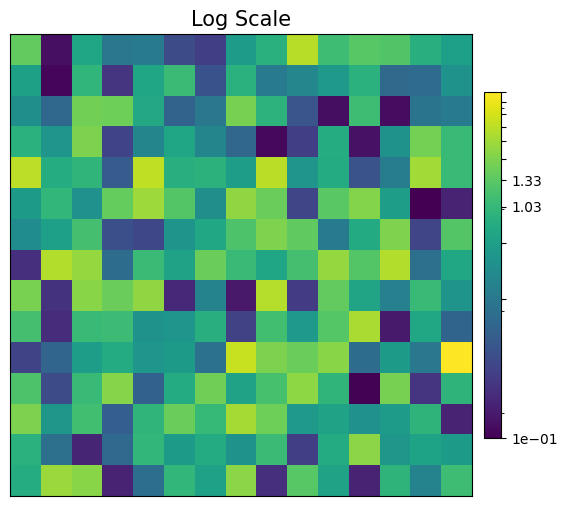

In [11]:
# For log scale, we need positive values
positive_array = np.abs(mixed_array) + 0.1  # Make all values positive and non-zero
array_glyph_positive = ArrayGlyph(positive_array)

fig3, ax3 = array_glyph_positive.plot(
    color_scale="sym-lognorm", cmap="viridis", title="Log Scale"
)

### 3.4 Midpoint Scale

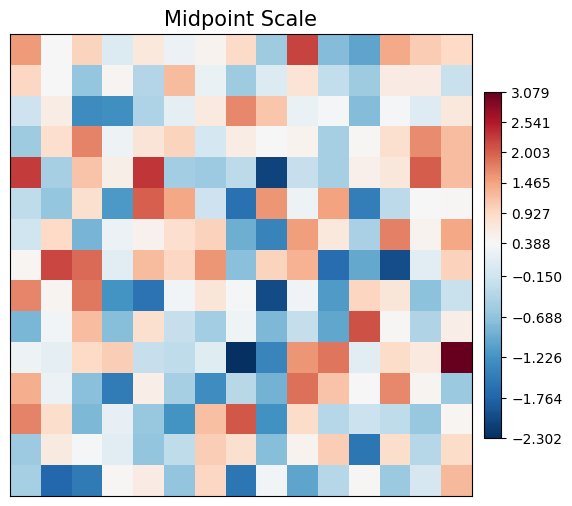

In [12]:
array_glyph_scales = ArrayGlyph(mixed_array)
fig4, ax4 = array_glyph_scales.plot(
    color_scale="midpoint",
    midpoint=0,  # Set the midpoint at 0
    cmap="RdBu_r",
    title="Midpoint Scale",
)

## 4. Displaying Cell Values
- The ArrayGlyph class can display the values of each cell in the array.

- Create a small array for better visibility of cell values

In [13]:
# Create a small array for better visibility of cell values
small_array = np.random.randint(0, 100, (5, 5))

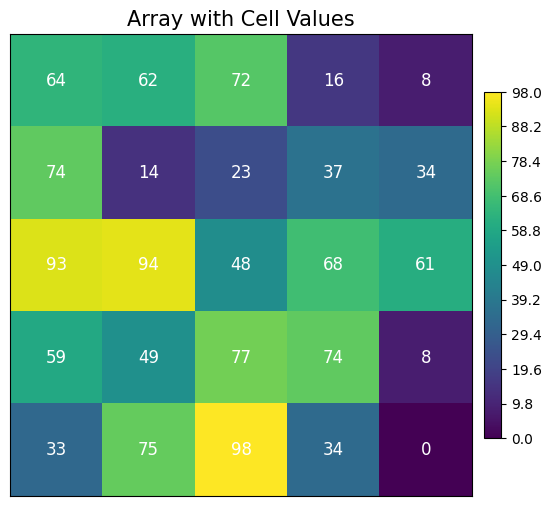

In [14]:
# Initialize the ArrayGlyph with the array
array_glyph_values = ArrayGlyph(small_array)

# Plot with cell values displayed
fig, ax = array_glyph_values.plot(
    display_cell_value=True,  # Display cell values
    num_size=12,  # Set text font size
    cmap="viridis",  # Use the viridis colormap
    title="Array with Cell Values",
    figsize=(8, 6),
)

## 5. Displaying Points on the Array
- The ArrayGlyph class can display points on top of the array.

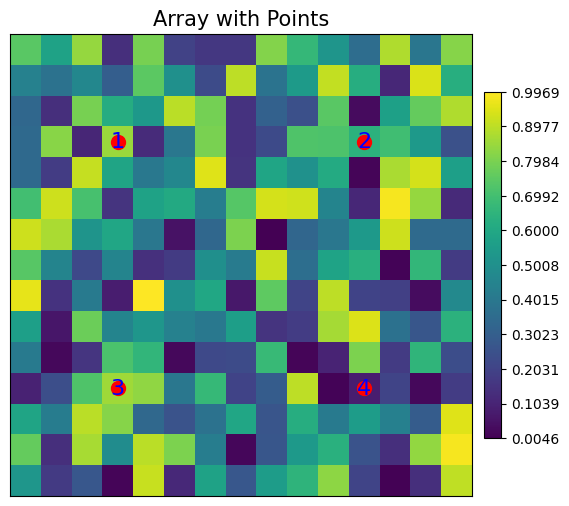

In [15]:
# Create an array
point_array = np.random.rand(15, 15)

# Create some points to display on the array
# Points are specified as [value, row, column] coordinates
points = np.array(
    [
        [1, 3, 3],  # Top-left region
        [2, 3, 11],  # Top-right region
        [3, 11, 3],  # Bottom-left region
        [4, 11, 11],  # Bottom-right region
    ]
)

# Style the points via a PointOverlay: locations plus marker/label styling
point_overlay = PointOverlay(
    points,
    color="red",  # Set point color
    size=100,  # Set point size
    label_color="blue",  # Set point-value label color
    label_size=16,  # Set point-value label size
)

# Initialize the ArrayGlyph with the array
array_glyph_points = ArrayGlyph(point_array)

# Plot with points
fig, ax = array_glyph_points.plot(
    points=point_overlay,  # Points to display
    cmap="viridis",  # Use the viridis colormap
    title="Array with Points",
    figsize=(10, 8),
)

## 6. Creating an Animation
- The ArrayGlyph class can create animations of arrays changing over time.

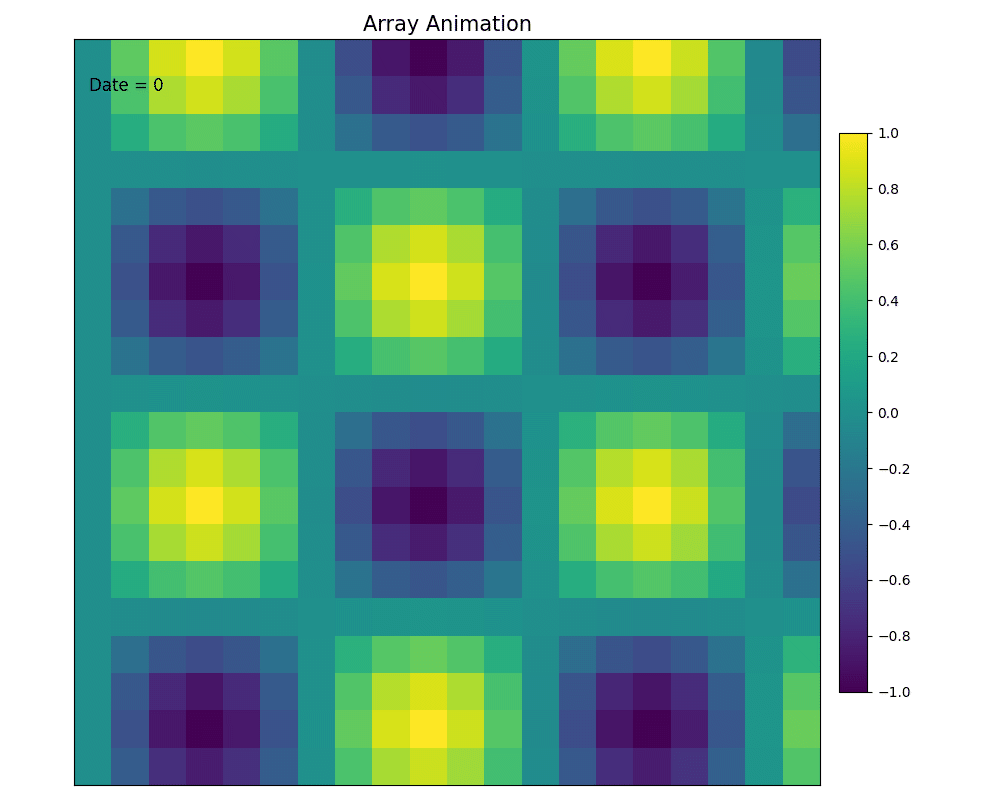

In [16]:
# Create a 3D array for the animation
n_frames = 10
x = np.linspace(0, 10, 20)
y = np.linspace(0, 10, 20)
X, Y = np.meshgrid(x, y)

# Create a 3D array with shape (n_frames, 20, 20)
animation_array = np.zeros((n_frames, 20, 20))
for i in range(n_frames):
    # Create a wave pattern that changes with time
    animation_array[i] = np.sin(X + i * 0.5) * np.cos(Y + i * 0.5)

# Initialize the ArrayGlyph with the 3D array
array_glyph_animation = ArrayGlyph(animation_array)

# Create the animation
anim = array_glyph_animation.animate(
    time=list(range(n_frames)),  # Time points
    points=None,  # No points to display
    interval=200,  # Interval between frames (ms)
    cmap="viridis",  # Use the viridis colormap
    title="Array Animation",
    figsize=(10, 8),
)

# Display the animation inline as a looping GIF. `embed_gif` renders it to a GIF
# wrapped in an IPython Image, which every notebook viewer plays (JupyterLab,
# the IDE, GitHub, the docs site) -- more portable than `anim.to_jshtml()`,
# whose embedded JavaScript some IDE notebook renderers do not run (the
# animation then shows as a single frozen frame). Close the animation's figure
# first so the inline backend does not also emit a stray static frame beside it.
plt.close(array_glyph_animation.fig)
embed_gif(anim, fps=5)

- Note: To save the animation, you would use:

In [17]:
array_glyph_animation.save_animation("animation.gif", fps=5)

In [18]:
os.listdir(".")

['animation.gif',
 'array_glyph_examples.ipynb',
 'reference_map.ipynb',
 'rgb_animation.ipynb']

## 7. Preparing Arrays with Different Methods
- The ArrayGlyph class provides methods for preparing arrays for visualization.

### 7.1 Preparing an Array with Cutoff Values

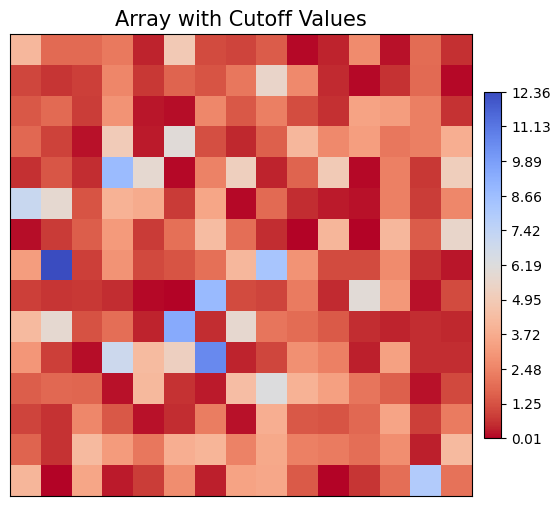

In [19]:
# Create an array with a wide range of values
wide_range_array = np.random.exponential(scale=2.0, size=(15, 15))

# Initialize the ArrayGlyph with cutoff values
array_glyph_cutoff = ArrayGlyph(
    wide_range_array,
    cutoff=[1.0, 5.0],  # Set minimum and maximum values
)

# Plot the array
fig, ax = array_glyph_cutoff.plot(title="Array with Cutoff Values", figsize=(8, 6))

### 7.2 Preparing an Array with Percentile Cutoff

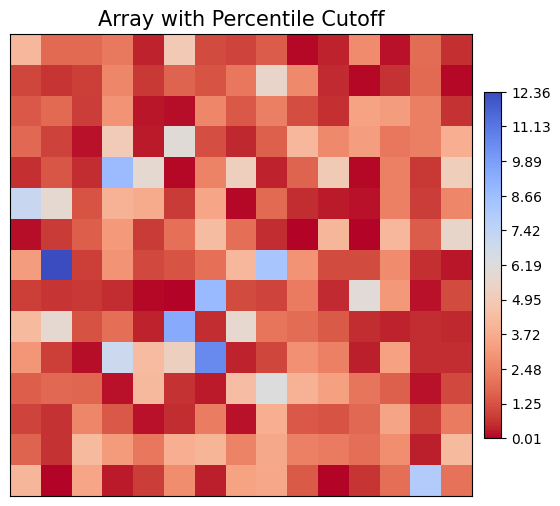

In [20]:
# Initialize the ArrayGlyph with percentile cutoff
array_glyph_percentile = ArrayGlyph(
    wide_range_array,
    percentile=2,  # Exclude values below 2nd percentile and above 98th percentile
)

# Plot the array
fig, ax = array_glyph_percentile.plot(
    title="Array with Percentile Cutoff", figsize=(8, 6)
)

### 7.3 Preparing an Array with Excluded Values

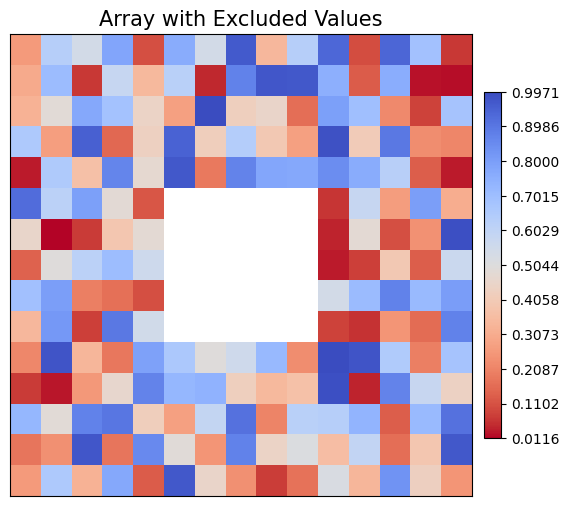

In [21]:
# Create an array with some specific values to exclude
exclude_array = np.random.rand(15, 15)
exclude_array[5:10, 5:10] = -9999  # Set some values to -9999 (to be excluded)

# Initialize the ArrayGlyph with excluded values
array_glyph_exclude = ArrayGlyph(
    exclude_array,
    exclude_value=[-9999],  # Exclude values equal to -9999
)

# Plot the array
fig, ax = array_glyph_exclude.plot(title="Array with Excluded Values", figsize=(8, 6))

## 8. Creating a Custom Colorbar
- The ArrayGlyph class allows customization of the colorbar.

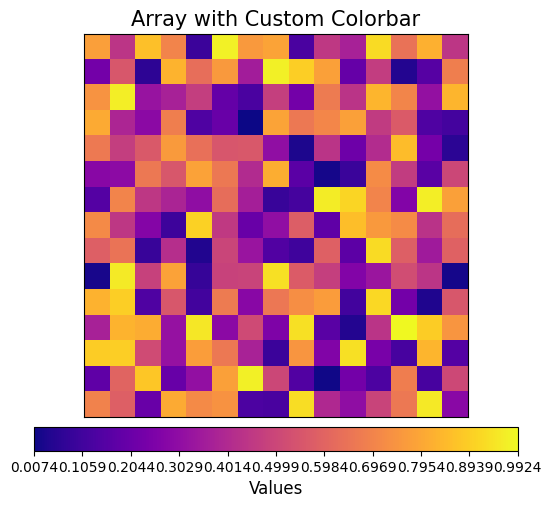

In [22]:
# Create an array
colorbar_array = np.random.default_rng(42).random((15, 15))

# Initialize the ArrayGlyph with the array
array_glyph_colorbar = ArrayGlyph(colorbar_array)

# Plot with a custom colorbar
fig, ax = array_glyph_colorbar.plot(
    colorbar=ColorBar(label="Values", length=0.8, orientation="horizontal"),
    cmap="plasma",  # Use the plasma colormap
    title="Array with Custom Colorbar",
    figsize=(10, 8),
)

## 9. Relief shading (hillshade) for DEMs

A DEM with a wide elevation range cannot be read from colour alone: a flat plain and a high plateau land on
different colours, but both look featureless. The `hillshade` option blends terrain **illumination** into the
colour-mapped surface, so it reads by *form* (slopes, ridges, valleys) independent of the elevation range.
Pass `hillshade=True` for defaults, or a dict to tune `vert_exag` (relief contrast), `azimuth`/`altitude`
(light position), `blend_mode`, or `multidirectional`.

In [23]:
# a wide-range synthetic DEM: a broad gentle plain plus a steep ridge and fine texture
yy, xx = np.mgrid[0:140, 0:180]
dem = (
    10
    + 0.3 * yy
    + 900 * np.exp(-(((xx - 130) / 20) ** 2 + ((yy - 70) / 45) ** 2))
    + 30 * np.sin(xx / 7) * np.cos(yy / 7)
)
dem.min(), dem.max()

(np.float64(-19.99994603115228), np.float64(939.1411834292655))

Colour only: the terrain colormap shows the big ridge, but the plain and the fine texture are almost flat.

(<Figure size 950x600 with 2 Axes>,
 <Axes: title={'center': 'terrain colormap only'}>)

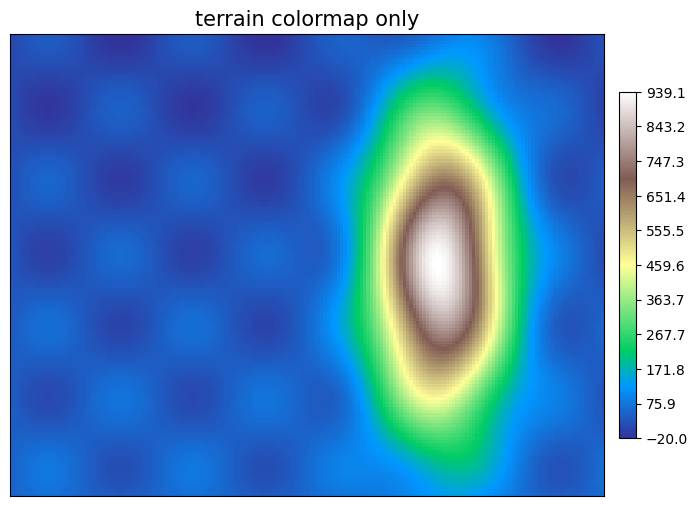

In [24]:
ArrayGlyph(dem, cmap='terrain').plot(title='terrain colormap only')

With `hillshade`: the same colormap, now relief-shaded, so every slope and ridge is legible -- and the
colorbar still reflects the elevation scale.

(<Figure size 950x600 with 2 Axes>, <Axes: title={'center': '+ hillshade'}>)

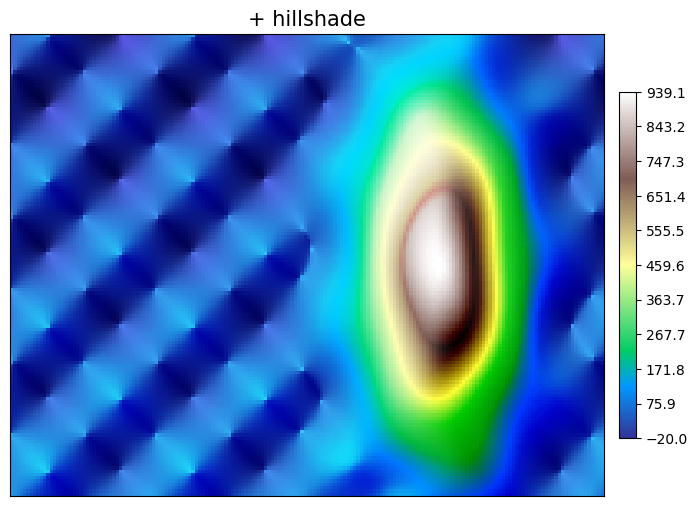

In [25]:
ArrayGlyph(dem, cmap='terrain', hillshade={'vert_exag': 8}).plot(title='+ hillshade')

The relief is the part colour alone could not provide. `hillshade` is a shared capability, not an ArrayGlyph
special case: it works the same way on any glyph whose data is a continuous surface -- `MeshGlyph` (a
triangulated terrain, `plot(z, location='node', hillshade=True)`) and `KDEGlyph` (relief-shading a density
surface). It composes with the `topography` data-style preset and the diverging `center=0` sea-level hinge.

## 10. Data-style presets via the `style=` option

Instead of choosing a colormap and scale by hand, pass `style=` a named preset from `cleopatra.colors.DATA_STYLES`. The preset owns the colormap, the norm (linear / log / symlog / diverging), the transparent nodata, any value-linked opacity, and — for categorical presets — a discrete legend. The same `style=` option works on `MeshGlyph` and `KDEGlyph` too, and composes with `hillshade`.

(<Figure size 950x600 with 1 Axes>,
 <Axes: title={'center': "style='topography' + hillshade"}>)

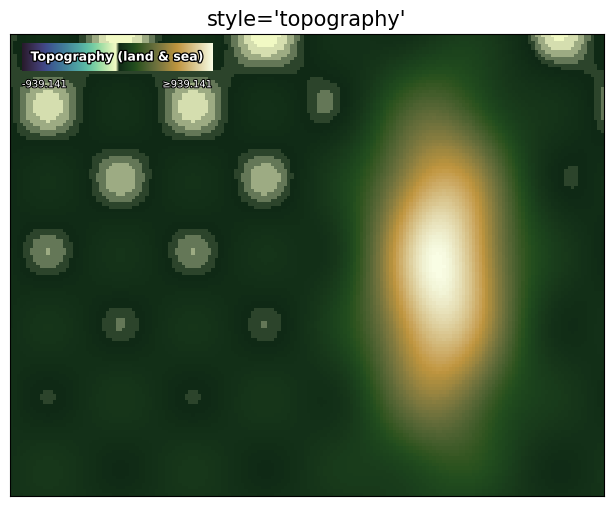

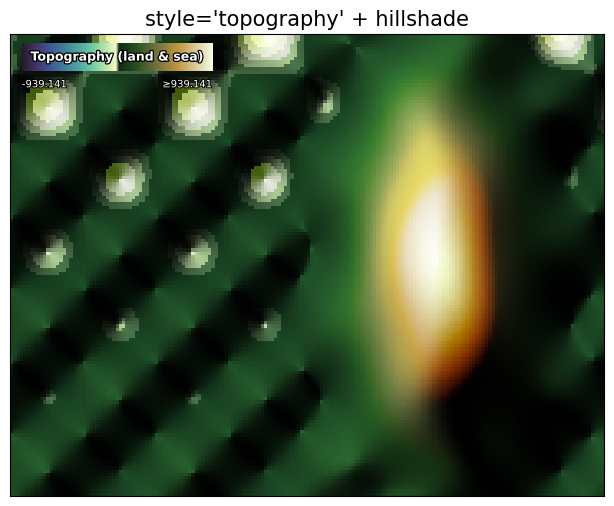

In [26]:
# A DEM styled by the 'topography' preset, and the same DEM relief-shaded (style + hillshade compose)
ArrayGlyph(dem, style='topography').plot(title="style='topography'")
ArrayGlyph(dem, style='topography', hillshade={'vert_exag': 8}).plot(
    title="style='topography' + hillshade"
)

Hydrology rasters have dedicated presets: `flow_accumulation` (symlog Blues, low cells fade) and the categorical `flow_direction_d8` (the eight D8 class codes with a discrete legend).

(<Figure size 780x600 with 1 Axes>,
 <Axes: title={'center': "style='flow_direction_d8'"}>)

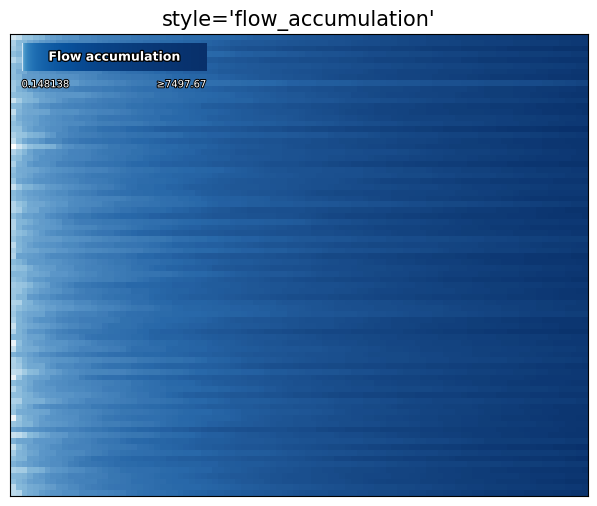

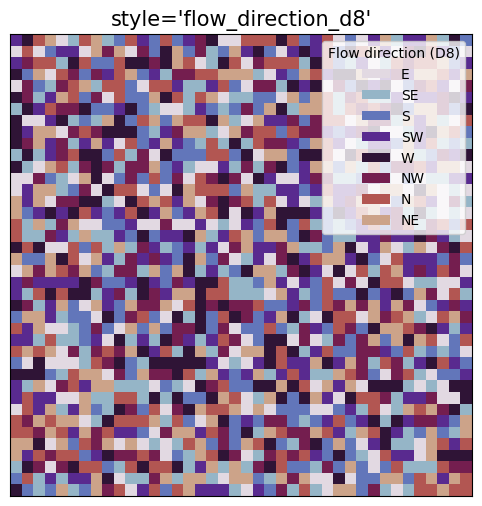

In [27]:
import numpy as np

# a synthetic flow-accumulation field and a D8 direction raster
accum = np.abs(np.random.default_rng(0).normal(size=(80, 100))).cumsum(axis=1) * 80
d8 = (
    np.random.default_rng(1)
    .choice([1, 2, 4, 8, 16, 32, 64, 128], size=(40, 40))
    .astype(float)
)
ArrayGlyph(accum, style='flow_accumulation').plot(title="style='flow_accumulation'")
ArrayGlyph(d8, style='flow_direction_d8').plot(title="style='flow_direction_d8'")

### Restyling an existing glyph: `apply_style()` and `.style`

You can apply -- or change -- a preset on a glyph that already exists, without rebuilding it. `apply_style(name)` re-renders the glyph **in place** by preset name, `glyph.style` reads the applied preset back, and the style is **sticky** (a later plain `plot()` keeps it) and **clearable** (`plot(style=None)`). `apply_style` takes ownership of the glyph's own axes -- don't use it on an axes shared with other content.

style before: None
style after apply_style: flow_accumulation
style after plot(style=None): None


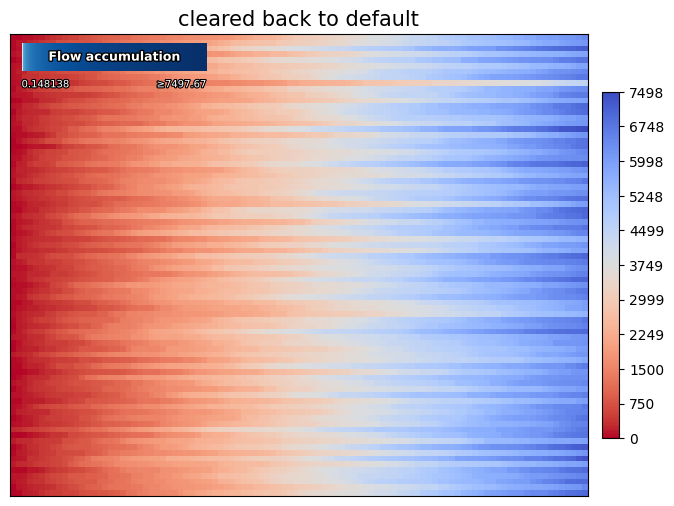

In [28]:
glyph = ArrayGlyph(accum)
glyph.plot(title='default colouring')
print('style before:', glyph.style)

glyph.apply_style('flow_accumulation')  # restyle in place, by name
print('style after apply_style:', glyph.style)

glyph.plot(title='still flow_accumulation (sticky)')  # a plain plot keeps it
glyph.plot(style=None, title='cleared back to default')
print('style after plot(style=None):', glyph.style)

## Summary
In this notebook, we've explored the ArrayGlyph class from the Cleopatra package.

We've seen how to:
1. Create and visualize simple arrays
2. Customize array visualizations
3. Use different color scales
4. Display cell values
5. Display points on arrays
6. Create animations
7. Prepare arrays with different methods
8. Create custom colorbars

The ArrayGlyph class provides powerful tools for visualizing and animating arrays.